# 06 — Baseline TF-IDF + Regressão Logística

Este notebook treina o primeiro modelo supervisionado da Sprint 3 para classificar chunks em `oportunidade` (1) e `nao_oportunidade` (0). O baseline combina TF-IDF de unigramas e bigramas com Regressão Logística.

> **Limite metodológico:** os alvos atuais são **pseudo-rótulos** produzidos pela concordância entre regras e BERTimbau. Portanto, as métricas deste notebook medem reprodução desses pseudo-rótulos, não desempenho real de negócio. A avaliação final exigirá os rótulos humanos da fila de auditoria.

## Decisões

- Usamos o split `train/validation` criado no notebook 05 e validamos novamente a ausência de reuniões compartilhadas.
- O TF-IDF é ajustado exclusivamente no treino para evitar vazamento de vocabulário.
- Unigramas capturam termos comerciais; bigramas capturam expressões como `proposta comercial` e `sem interesse`.
- `min_df=2` reduz termos acidentais e `max_df=0.98` remove termos quase universais.
- `class_weight=balanced` reduz o efeito do desbalanceamento inicial.
- O limiar permanece em 0,5; não usamos a validação para otimizá-lo nesta primeira referência.
- A métrica principal é o recall da classe oportunidade, pois perder uma oportunidade relevante tende a ser mais custoso do que encaminhar um falso positivo para revisão.
- Nenhuma transcrição é exibida ou salva nos relatórios versionáveis.

In [ ]:
from __future__ import annotations

import json
import os
import platform
import tempfile
import time
from collections import Counter
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "wedjat-matplotlib"))

import joblib
import matplotlib.pyplot as plt
import numpy as np
import sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

SEED = 42
THRESHOLD = 0.5

def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError("Raiz do projeto não encontrada. No Colab, entre na pasta Wedjat.")

ROOT = find_project_root()
DATA_PATH = ROOT / "data/processed/pseudo_labels_opportunity.jsonl"
METRICS_PATH = ROOT / "reports/metrics/baseline_tfidf_logreg_metrics.json"
FIGURE_PATH = ROOT / "reports/figures/baseline_tfidf_logreg_confusion_matrix.png"
PREDICTIONS_PATH = ROOT / "data/processed/baseline_tfidf_logreg_validation_predictions.jsonl"
ERRORS_PATH = ROOT / "data/processed/baseline_tfidf_logreg_errors.jsonl"
MODEL_PATH = ROOT / "data/processed/baseline_tfidf_logreg.joblib"

print({
    "python": platform.python_version(),
    "numpy": np.__version__,
    "scikit_learn": sklearn.__version__,
})

{'python': '3.12.10', 'numpy': '2.5.3', 'scikit_learn': '1.9.1'}


## Leitura e validação do split

Além de conferir esquema e classes, a célula interrompe a execução caso uma reunião apareça simultaneamente no treino e na validação.

In [ ]:
def read_jsonl(path: Path) -> list[dict]:
    with path.open(encoding="utf-8") as file:
        return [json.loads(line) for line in file if line.strip()]

rows = read_jsonl(DATA_PATH)
required_fields = {"meeting_id", "chunk_id", "text", "pseudo_label", "weak_split"}
assert rows, "Arquivo de pseudo-rótulos vazio. Execute o notebook 05."
assert all(required_fields <= row.keys() for row in rows), "Esquema de entrada inválido."
assert {row["pseudo_label"] for row in rows} == {0, 1}, "As duas classes precisam estar presentes."
assert {row["weak_split"] for row in rows} == {"train", "validation"}

train_rows = [row for row in rows if row["weak_split"] == "train"]
validation_rows = [row for row in rows if row["weak_split"] == "validation"]
train_meetings = {row["meeting_id"] for row in train_rows}
validation_meetings = {row["meeting_id"] for row in validation_rows}
meeting_overlap = train_meetings & validation_meetings
assert not meeting_overlap, f"Vazamento detectado em {len(meeting_overlap)} reuniões."

X_train_text = [row["text"] for row in train_rows]
y_train = np.asarray([row["pseudo_label"] for row in train_rows], dtype=np.int64)
X_validation_text = [row["text"] for row in validation_rows]
y_validation = np.asarray([row["pseudo_label"] for row in validation_rows], dtype=np.int64)

print({
    "train_chunks": len(train_rows),
    "validation_chunks": len(validation_rows),
    "train_meetings": len(train_meetings),
    "validation_meetings": len(validation_meetings),
    "train_labels": dict(Counter(y_train.tolist())),
    "validation_labels": dict(Counter(y_validation.tolist())),
    "meeting_overlap": len(meeting_overlap),
})

{'train_chunks': 539, 'validation_chunks': 140, 'train_meetings': 388, 'validation_meetings': 98, 'train_labels': {1: 218, 0: 321}, 'validation_labels': {0: 82, 1: 58}, 'meeting_overlap': 0}


## Treinamento

O `TfidfVectorizer` e a Regressão Logística são armazenados juntos apenas em `data/processed/`, pasta ignorada pelo Git. Isso preserva a reprodutibilidade local sem versionar um vocabulário derivado das transcrições.

In [3]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.98,
    max_features=50_000,
    sublinear_tf=True,
    dtype=np.float32,
)
classifier = LogisticRegression(
    C=1.0,
    class_weight="balanced",
    max_iter=2_000,
    solver="liblinear",
    random_state=SEED,
)

fit_started = time.perf_counter()
X_train = vectorizer.fit_transform(X_train_text)
classifier.fit(X_train, y_train)
fit_seconds = time.perf_counter() - fit_started

transform_started = time.perf_counter()
X_validation = vectorizer.transform(X_validation_text)
validation_probabilities = classifier.predict_proba(X_validation)[:, 1]
inference_seconds = time.perf_counter() - transform_started
validation_predictions = (validation_probabilities >= THRESHOLD).astype(np.int64)

MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump({"vectorizer": vectorizer, "classifier": classifier}, MODEL_PATH)

print({
    "features": len(vectorizer.vocabulary_),
    "fit_seconds": round(fit_seconds, 4),
    "validation_inference_seconds": round(inference_seconds, 4),
    "iterations": int(classifier.n_iter_[0]),
})

{'features': 16582, 'fit_seconds': 0.3827, 'validation_inference_seconds': 0.0613, 'iterations': 4}


## Métricas no conjunto de validação

Relatamos accuracy, precision, recall e F1 para a classe positiva, além das médias macro e weighted. A matriz segue a ordem `[[TN, FP], [FN, TP]]`.

In [4]:
matrix = confusion_matrix(y_validation, validation_predictions, labels=[0, 1])
report = classification_report(
    y_validation,
    validation_predictions,
    labels=[0, 1],
    target_names=["nao_oportunidade", "oportunidade"],
    output_dict=True,
    zero_division=0,
)
metrics = {
    "accuracy": float(accuracy_score(y_validation, validation_predictions)),
    "precision_oportunidade": float(precision_score(y_validation, validation_predictions, pos_label=1, zero_division=0)),
    "recall_oportunidade": float(recall_score(y_validation, validation_predictions, pos_label=1, zero_division=0)),
    "f1_oportunidade": float(f1_score(y_validation, validation_predictions, pos_label=1, zero_division=0)),
    "precision_macro": float(precision_score(y_validation, validation_predictions, average="macro", zero_division=0)),
    "recall_macro": float(recall_score(y_validation, validation_predictions, average="macro", zero_division=0)),
    "f1_macro": float(f1_score(y_validation, validation_predictions, average="macro", zero_division=0)),
    "precision_weighted": float(precision_score(y_validation, validation_predictions, average="weighted", zero_division=0)),
    "recall_weighted": float(recall_score(y_validation, validation_predictions, average="weighted", zero_division=0)),
    "f1_weighted": float(f1_score(y_validation, validation_predictions, average="weighted", zero_division=0)),
}
tn, fp, fn, tp = (int(value) for value in matrix.ravel())

print({
    "accuracy": round(metrics["accuracy"], 4),
    "precision_oportunidade": round(metrics["precision_oportunidade"], 4),
    "recall_oportunidade": round(metrics["recall_oportunidade"], 4),
    "f1_oportunidade": round(metrics["f1_oportunidade"], 4),
    "f1_macro": round(metrics["f1_macro"], 4),
    "confusion_matrix": matrix.tolist(),
})

{'accuracy': 0.9571, 'precision_oportunidade': 0.9062, 'recall_oportunidade': 1.0, 'f1_oportunidade': 0.9508, 'f1_macro': 0.9564, 'confusion_matrix': [[76, 6], [0, 58]]}


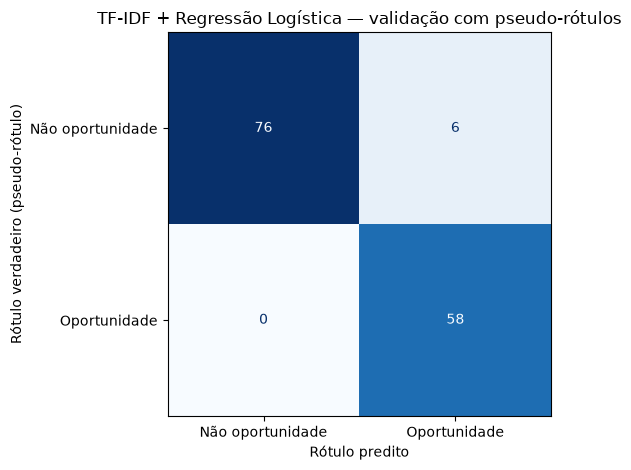

In [5]:
FIGURE_PATH.parent.mkdir(parents=True, exist_ok=True)
display = ConfusionMatrixDisplay(
    confusion_matrix=matrix, display_labels=["Não oportunidade", "Oportunidade"]
)
display.plot(cmap="Blues", values_format="d", colorbar=False)
display.ax_.set_xlabel("Rótulo predito")
display.ax_.set_ylabel("Rótulo verdadeiro (pseudo-rótulo)")
plt.title("TF-IDF + Regressão Logística — validação com pseudo-rótulos")
plt.tight_layout()
plt.savefig(FIGURE_PATH, dpi=160, bbox_inches="tight")
plt.show()

## Artefatos e análise de erros

O relatório versionável contém somente números agregados. As previsões e o manifesto de erros ficam em `data/processed/`, sem o texto, e permitem localizar os chunks para revisão controlada.

In [6]:
prediction_rows = []
for row, expected, predicted, probability in zip(
    validation_rows, y_validation, validation_predictions, validation_probabilities
):
    prediction_rows.append({
        "meeting_id": row["meeting_id"],
        "chunk_id": row["chunk_id"],
        "pseudo_label": int(expected),
        "prediction": int(predicted),
        "probability_oportunidade": round(float(probability), 8),
        "correct_against_pseudo_label": bool(expected == predicted),
    })
error_rows = [row for row in prediction_rows if not row["correct_against_pseudo_label"]]

for path, output_rows in [(PREDICTIONS_PATH, prediction_rows), (ERRORS_PATH, error_rows)]:
    with path.open("w", encoding="utf-8") as file:
        for row in output_rows:
            file.write(json.dumps(row, ensure_ascii=False) + "\n")

summary = {
    "schema_version": "1.0",
    "model": "TF-IDF + LogisticRegression",
    "target": "oportunidade_comercial_binaria_no_chunk",
    "evaluation_reference": "pseudo_labels_rule_and_bert_agreement",
    "warning": "Estas métricas não estimam desempenho real; falta avaliação contra rótulos humanos.",
    "seed": SEED,
    "threshold": THRESHOLD,
    "train_chunks": len(train_rows),
    "validation_chunks": len(validation_rows),
    "train_meetings": len(train_meetings),
    "validation_meetings": len(validation_meetings),
    "meeting_overlap": len(meeting_overlap),
    "train_label_counts": dict(Counter(str(value) for value in y_train.tolist())),
    "validation_label_counts": dict(Counter(str(value) for value in y_validation.tolist())),
    "vectorizer": {
        "ngram_range": [1, 2],
        "min_df": 2,
        "max_df": 0.98,
        "max_features": 50000,
        "actual_features": len(vectorizer.vocabulary_),
        "sublinear_tf": True,
    },
    "classifier": {
        "C": 1.0,
        "class_weight": "balanced",
        "solver": "liblinear",
        "iterations": int(classifier.n_iter_[0]),
    },
    "metrics": metrics,
    "classification_report": report,
    "confusion_matrix_order": [["TN", "FP"], ["FN", "TP"]],
    "confusion_matrix": matrix.tolist(),
    "error_counts": {"false_positive": fp, "false_negative": fn, "total": len(error_rows)},
    "primary_metric": {
        "name": "recall_oportunidade",
        "value": metrics["recall_oportunidade"],
        "justification": "Perder uma oportunidade relevante tende a ser mais custoso do que revisar um falso positivo.",
    },
    "fit_seconds": fit_seconds,
    "validation_inference_seconds": inference_seconds,
    "python_version": platform.python_version(),
    "numpy_version": np.__version__,
    "scikit_learn_version": sklearn.__version__,
}
METRICS_PATH.parent.mkdir(parents=True, exist_ok=True)
METRICS_PATH.write_text(json.dumps(summary, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")

print({
    "saved_metrics": str(METRICS_PATH.relative_to(ROOT)),
    "saved_figure": str(FIGURE_PATH.relative_to(ROOT)),
    "validation_predictions": len(prediction_rows),
    "errors_without_text": len(error_rows),
})

{'saved_metrics': 'reports\\metrics\\baseline_tfidf_logreg_metrics.json', 'saved_figure': 'reports\\figures\\baseline_tfidf_logreg_confusion_matrix.png', 'validation_predictions': 140, 'errors_without_text': 6}


## Interpretação e próximo passo

Este resultado estabelece uma referência barata, rápida e interpretável. Como parte dos pseudo-rótulos veio de sinais lexicais, o TF-IDF pode reproduzir as regras e apresentar uma estimativa otimista. O notebook 07 deverá treinar o BERTimbau com o mesmo split e o notebook 08 fará a comparação. Nenhum dos dois substituirá a avaliação final no conjunto humano reservado.